# Partiti segment workflow (experimental)

This notebook is a first-pass port of `run_partiti_segment_workflow.py` for interactive development and eventual migration into `binit`.

In [1]:
from __future__ import annotations

from pathlib import Path
import polars as pl
import os 
from rolypoly.utils.bio.polars_fastx import frame_to_fastx, load_sequences
from itables import init_notebook_mode
# Enable interactive mode for all future cells
init_notebook_mode(all_interactive=True)

threads: int = 8
ani_min_identity: float = 0.9
ani_min_af: float = 0.8
min_correlation: float = 0.1
min_prevalence: float = 0.05
min_shared_samples: int = 1
termini_length: str = "4-1145"
termini_distance: int = 0
reuse_extend: bool = False
write_single_rdrp_strict: bool = False
log_level: str = "debug"

rp_dir = os.environ.get("RP_DIR", "../../../")
rdrp_fasta=Path(rp_dir) / "testing_folder/inputs/partiti_usecase/ynp_rdrps.fasta"
cp_fasta=Path(rp_dir) / "testing_folder/inputs/partiti_usecase/ynp_cps.fasta"
outdir=Path(rp_dir) / "testing_folder/outputs/partiti_usecase"
outdir.mkdir(parents=True, exist_ok=True)


#### prepare inputs


In [2]:
rdrp_df = load_sequences(rdrp_fasta).with_columns(pl.lit("RdRp").alias("marker_type"))
cp_df = load_sequences(cp_fasta).with_columns(pl.lit("CP").alias("marker_type"))
combined = pl.concat(
    [rdrp_df, cp_df],
    how="vertical_relaxed",
).with_columns(
    pl.col("contig_id").str.extract(r"^(.*?)(_.*)?$").alias("sample_id")
    .alias("sample_id")
)
combined_fasta = outdir / "combined_rdrp_cp.fasta"
frame_to_fastx(
    combined.select(pl.col("contig_id").alias("header"), pl.col("sequence")),
    combined_fasta,
)

combined

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


### Clustering all contigs
next couple of cells test the different backends - the results are too different, need to figure out why

Test 1 - pyfastani backend

In [ ]:
%%bash
set -euo pipefail
cd ../../../
OUTDIR="testing_folder/outputs/partiti_usecase"
TIMELOG="${OUTDIR}/cluster_timing.log"
mkdir -p "${OUTDIR}"
echo "=== $(date -Is) backend=pyfastani ===" >> "${TIMELOG}"
/usr/bin/time -f "backend=pyfastani wall_s=%e user_cpu_s=%U sys_cpu_s=%S max_rss_kb=%M" \
  pixi run rolypoly cluster \
    -i testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta \
    --ani-backend pyfastani \
    --clustering-method centroid \
    --min-identity 90.0 \
    --min-target-coverage 80.0 \
    -o testing_folder/outputs/partiti_usecase/cluster_assignments_pyfastani.tsv \
    --summary-output testing_folder/outputs/partiti_usecase/cluster_summary_pyfastani.tsv \
    --representatives-fasta testing_folder/outputs/partiti_usecase/cluster_representatives_pyfastani.fasta \
    -t 8 \
    -ll debug 2> >(tee -a "${TIMELOG}" >&2)

DEBUG    Original command called: /clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/.pixi/envs/dev/bin/rolypoly cluster -i       loggit.py:201
         testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta --ani-backend pyfastani --clustering-method centroid                           
         --min-identity 90.0 --min-target-coverage 80.0 -o testing_folder/outputs/partiti_usecase/cluster_assignments_pyfastani.tsv                   
         --summary-output testing_folder/outputs/partiti_usecase/cluster_summary_pyfastani.tsv --representatives-fasta                                
         testing_folder/outputs/partiti_usecase/cluster_representatives_pyfastani.fasta -t 8 -ll debug                                                
DEBUG    RolyPoly version: {'code': 'f645f4b', 'data': 'Unknown'}                                                                        loggit.py:203
DEBUG    Launch location: /clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly           

Test 2 - blastn backend

In [ ]:
%%bash
set -euo pipefail
cd ../../../
OUTDIR="testing_folder/outputs/partiti_usecase"
TIMELOG="${OUTDIR}/cluster_timing.log"
mkdir -p "${OUTDIR}"
echo "=== $(date -Is) backend=blastn ===" >> "${TIMELOG}"
/usr/bin/time -f "backend=blastn wall_s=%e user_cpu_s=%U sys_cpu_s=%S max_rss_kb=%M" \
  pixi run rolypoly cluster \
    -i testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta \
    --ani-backend blastn \
    --clustering-method centroid \
    --min-identity 90.0 \
    --min-target-coverage 80.0 \
    -o testing_folder/outputs/partiti_usecase/cluster_assignments_blastn.tsv \
    --summary-output testing_folder/outputs/partiti_usecase/cluster_summary_blastn.tsv \
    --representatives-fasta testing_folder/outputs/partiti_usecase/cluster_representatives_blastn.fasta \
    -t 8 \
    -ll debug 2> >(tee -a "${TIMELOG}" >&2)

DEBUG    Original command called: /clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/.pixi/envs/dev/bin/rolypoly cluster -i       ]8;id=863831;file:///clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/src/rolypoly/utils/logging/loggit.py\loggit.py]8;;\:]8;id=495950;file:///clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/src/rolypoly/utils/logging/loggit.py#165\165]8;;\
         testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta --ani-backend blastn --clustering-method centroid --min-identity               
         90.0 --min-target-coverage 80.0 -o testing_folder/outputs/partiti_usecase/cluster_assignments_blastn.tsv --summary-output                    
         testing_folder/outputs/partiti_usecase/cluster_summary_blastn.tsv --representatives-fasta                                                    
         testing_folder/outputs/partiti_usecase/cluster_representatives_blastn.fasta -t 8 -ll debug                                             

In [ ]:
%%bash
set -euo pipefail
cd ../../../
OUTDIR="testing_folder/outputs/partiti_usecase"
TIMELOG="${OUTDIR}/cluster_timing.log"
mkdir -p "${OUTDIR}"
for backend in pyskani mmseqs kmer; do
  echo "=== $(date -Is) backend=${backend} ===" >> "${TIMELOG}"
  /usr/bin/time -f "backend=${backend} wall_s=%e user_cpu_s=%U sys_cpu_s=%S max_rss_kb=%M" \
    pixi run -e cluster rolypoly cluster \
      -i testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta \
      --ani-backend "$backend" \
      --clustering-method centroid \
      --min-identity 90.0 \
      --min-target-coverage 80.0 \
      -o "testing_folder/outputs/partiti_usecase/cluster_assignments_${backend}.tsv" \
      --summary-output "testing_folder/outputs/partiti_usecase/cluster_summary_${backend}.tsv" \
      --representatives-fasta "testing_folder/outputs/partiti_usecase/cluster_representatives_${backend}.fasta" \
      -t 8 \
      -ll debug 2> >(tee -a "${TIMELOG}" >&2)
done

DEBUG    Original command called: /clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/.pixi/envs/cluster/bin/rolypoly cluster -i   ]8;id=396457;file:///clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/src/rolypoly/utils/logging/loggit.py\loggit.py]8;;\:]8;id=926982;file:///clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/src/rolypoly/utils/logging/loggit.py#165\165]8;;\
         testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta --ani-backend pyskani --clustering-method centroid --min-identity              
         90.0 --min-target-coverage 80.0 -o testing_folder/outputs/partiti_usecase/cluster_assignments_pyskani.tsv --summary-output                   
         testing_folder/outputs/partiti_usecase/cluster_summary_pyskani.tsv --representatives-fasta                                                   
         testing_folder/outputs/partiti_usecase/cluster_representatives_pyskani.fasta -t 8 -ll debug                                            

Test 3 - additional backends (pyskani, mmseqs, kmer)

read clustering results and validate all backend outputs before continuing

In [ ]:
# Read backend-specific clustering outputs and compare them against blastn.
backend_names = ["blastn", "pyfastani", "pyskani", "mmseqs", "kmer"]

cluster_assignments_by_backend: dict[str, pl.DataFrame] = {}
cluster_summary_by_backend: dict[str, pl.DataFrame] = {}

for backend in backend_names:
    assignments_path = outdir / f"cluster_assignments_{backend}.tsv"
    summary_path = outdir / f"cluster_summary_{backend}.tsv"
    if not assignments_path.exists() or not summary_path.exists():
        raise FileNotFoundError(
            f"Missing clustering outputs for backend '{backend}'. "
            f"Expected: {assignments_path} and {summary_path}"
        )
    cluster_assignments_by_backend[backend] = pl.read_csv(
        assignments_path, separator="\t"
    )
    cluster_summary_by_backend[backend] = pl.read_csv(
        summary_path, separator="\t"
    )

comparison_rows: list[dict[str, float | int | str]] = []
for backend in backend_names:
    summary_df = cluster_summary_by_backend[backend]
    n_clusters = int(summary_df.height)
    singleton_fraction = float(
        summary_df.select((pl.col("member_count") == 1).mean()).item()
    )
    largest_cluster = int(summary_df.select(pl.col("member_count").max()).item())
    comparison_rows.append(
        {
            "backend": backend,
            "n_clusters": n_clusters,
            "singleton_fraction": round(singleton_fraction, 3),
            "largest_cluster": largest_cluster,
        }
    )

backend_comparison = pl.DataFrame(comparison_rows).sort("backend")

# Compare each backend against blastn as the baseline.
blastn_n_clusters = int(
    backend_comparison.filter(pl.col("backend") == "blastn")
    .select("n_clusters")
    .item()
)
blastn_singleton_fraction = float(
    backend_comparison.filter(pl.col("backend") == "blastn")
    .select("singleton_fraction")
    .item()
)

comparison_vs_blastn = (
    backend_comparison
    .filter(pl.col("backend") != "blastn")
    .with_columns(
        pl.max_horizontal(
            pl.col("n_clusters") / max(blastn_n_clusters, 1),
            pl.lit(blastn_n_clusters) / pl.max_horizontal(pl.col("n_clusters"), pl.lit(1)),
        ).alias("cluster_count_ratio_vs_blastn"),
        (pl.col("singleton_fraction") - blastn_singleton_fraction)
        .abs()
        .alias("singleton_fraction_delta_vs_blastn"),
    )
    .sort("backend")
)

# Flag backend mismatch but do not stop execution. Continue with blastn baseline.
failed_backends = comparison_vs_blastn.filter(
    (pl.col("cluster_count_ratio_vs_blastn") > 3.0)
    | (pl.col("singleton_fraction_delta_vs_blastn") > 0.30)
)
backend_mismatch_detected = failed_backends.height > 0
if backend_mismatch_detected:
    print(
        "WARNING: Clustering backend mismatch is too large for reliable cross-backend equivalence. "
        "Continuing downstream analysis with blastn baseline only."
    )
    print(failed_backends)
else:
    print("All tested backends are within mismatch thresholds vs blastn.")

# Continue with blastn assignments as a temporary baseline after checks.
cluster_assignments = cluster_assignments_by_backend["blastn"]

backend_comparison

shape: (3, 6)
┌───────────┬────────────┬──────────────────┬─────────────────┬──────────────────┬─────────────────┐
│ backend   ┆ n_clusters ┆ singleton_fracti ┆ largest_cluster ┆ cluster_count_ra ┆ singleton_fract │
│ ---       ┆ ---        ┆ on               ┆ ---             ┆ tio_vs_blastn    ┆ ion_delta_vs_bl │
│ str       ┆ i64        ┆ ---              ┆ i64             ┆ ---              ┆ …               │
│           ┆            ┆ f64              ┆                 ┆ f64              ┆ ---             │
│           ┆            ┆                  ┆                 ┆                  ┆ f64             │
╞═══════════╪════════════╪══════════════════╪═════════════════╪══════════════════╪═════════════════╡
│ kmer      ┆ 4339       ┆ 0.872            ┆ 72              ┆ 48.211111        ┆ 0.483           │
│ pyfastani ┆ 1597       ┆ 0.957            ┆ 1110            ┆ 17.744444        ┆ 0.568           │
│ pyskani   ┆ 5379       ┆ 0.983            ┆ 85              ┆ 59.766667    

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


### Backend difference diagnostics
Investigate why results diverge even under the same CLI thresholds by quantifying agreement against the `blastn` baseline.

In [ ]:
import random

# Build per-backend seq -> cluster mapping from assignment tables.
cluster_map_by_backend: dict[str, dict[str, str]] = {}
cluster_size_by_backend: dict[str, dict[str, int]] = {}

for backend in backend_names:
    assignments_df = cluster_assignments_by_backend[backend].select("seq_id", "cluster_id")
    cluster_map_by_backend[backend] = {
        seq_id: cluster_id
        for seq_id, cluster_id in assignments_df.iter_rows()
    }
    size_df = assignments_df.group_by("cluster_id").len().rename({"len": "cluster_size"})
    cluster_size_by_backend[backend] = {
        cluster_id: int(cluster_size)
        for cluster_id, cluster_size in size_df.iter_rows()
    }

# Sequence universe for pairwise co-clustering agreement.
seq_ids = sorted(cluster_map_by_backend["blastn"].keys())
print(f"Total sequences compared: {len(seq_ids)}")

# Sample random sequence pairs and compare whether each pair is co-clustered.
sample_pairs = 200000
rng = random.Random(7)
pair_indices = [
    (rng.randrange(len(seq_ids)), rng.randrange(len(seq_ids)))
    for _ in range(sample_pairs)
 ]

def pair_is_coclustered(backend: str, i: int, j: int) -> bool:
    seq_i = seq_ids[i]
    seq_j = seq_ids[j]
    return cluster_map_by_backend[backend][seq_i] == cluster_map_by_backend[backend][seq_j]

agreement_rows: list[dict[str, float | str]] = []
for backend in [b for b in backend_names if b != "blastn"]:
    same_blastn = 0
    same_backend = 0
    same_both = 0
    mismatch = 0

    for i, j in pair_indices:
        in_blastn = pair_is_coclustered("blastn", i, j)
        in_backend = pair_is_coclustered(backend, i, j)
        same_blastn += int(in_blastn)
        same_backend += int(in_backend)
        same_both += int(in_blastn and in_backend)
        mismatch += int(in_blastn != in_backend)

    # Jaccard of co-clustered pairs (estimated from sampled pairs).
    union = same_blastn + same_backend - same_both
    co_cluster_jaccard = (same_both / union) if union > 0 else 0.0
    pairwise_disagreement = mismatch / sample_pairs

    # Sequence-level cluster-size shift vs blastn.
    deltas = []
    for seq_id in seq_ids:
        c_blastn = cluster_map_by_backend["blastn"][seq_id]
        c_backend = cluster_map_by_backend[backend][seq_id]
        s_blastn = cluster_size_by_backend["blastn"][c_blastn]
        s_backend = cluster_size_by_backend[backend][c_backend]
        deltas.append(abs(s_backend - s_blastn))

    delta_df = pl.DataFrame({"delta": deltas})
    median_abs_cluster_size_delta = float(delta_df.select(pl.col("delta").median()).item())
    p90_abs_cluster_size_delta = float(delta_df.select(pl.col("delta").quantile(0.9)).item())

    agreement_rows.append(
        {
            "backend": backend,
            "co_cluster_jaccard_vs_blastn": round(co_cluster_jaccard, 4),
            "pairwise_disagreement_rate": round(pairwise_disagreement, 4),
            "median_abs_cluster_size_delta": round(median_abs_cluster_size_delta, 2),
            "p90_abs_cluster_size_delta": round(p90_abs_cluster_size_delta, 2),
        }
    )

backend_difference_diagnostics = pl.DataFrame(agreement_rows).sort("pairwise_disagreement_rate")
backend_difference_diagnostics

Total sequences compared: 6054


Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [ ]:
%%bash
set -euo pipefail
cd ../../../
OUTDIR="testing_folder/outputs/partiti_usecase"
TIMELOG="${OUTDIR}/cluster_timing.log"
mkdir -p "${OUTDIR}"
# Non-overlapping preset subset (exclude backend-mirror presets)
PRESETS=("miuvig-species" "checkv" "cd-hit" "genus" "leiden-community")
for preset in "${PRESETS[@]}"; do
  echo "Running preset: ${preset}"
  echo "=== $(date -Is) preset=${preset} ===" >> "${TIMELOG}"
  /usr/bin/time -f "preset=${preset} wall_s=%e user_cpu_s=%U sys_cpu_s=%S max_rss_kb=%M" \
    pixi run -e cluster rolypoly cluster \
      -i testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta \
      --preset "${preset}" \
      -o "testing_folder/outputs/partiti_usecase/cluster_assignments_preset_${preset}.tsv" \
      --summary-output "testing_folder/outputs/partiti_usecase/cluster_summary_preset_${preset}.tsv" \
      --representatives-fasta "testing_folder/outputs/partiti_usecase/cluster_representatives_preset_${preset}.fasta" \
      -t 8 \
      -ll debug 2> >(tee -a "${TIMELOG}" >&2) || echo "Preset failed: ${preset}"
done

Running preset: miuvig-species
INFO     Using preset 'miuvig-species': MIUViG species-level vOTU (95% ANI, 85% AF, blastn, centroid)                                   ]8;id=842249;file:///clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/src/rolypoly/commands/bining/cluster.py\cluster.py]8;;\:]8;id=114590;file:///clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/src/rolypoly/commands/bining/cluster.py#840\840]8;;\
DEBUG    Original command called: /clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/.pixi/envs/cluster/bin/rolypoly cluster -i   ]8;id=447212;file:///clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/src/rolypoly/utils/logging/loggit.py\loggit.py]8;;\:]8;id=423682;file:///clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/src/rolypoly/utils/logging/loggit.py#165\165]8;;\
         testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta --preset miuvig-species -o                                                     
      

In [ ]:
preset_names = [
    "miuvig-species",
    "checkv",
    "cd-hit",
    "genus",
    "leiden-community",
]

preset_summary_rows: list[dict[str, str | int | float]] = []
preset_cluster_maps: dict[str, dict[str, str]] = {}

for preset in preset_names:
    assignments_path = outdir / f"cluster_assignments_preset_{preset}.tsv"
    summary_path = outdir / f"cluster_summary_preset_{preset}.tsv"
    if not assignments_path.exists() or not summary_path.exists():
        preset_summary_rows.append(
            {
                "preset": preset,
                "status": "missing_or_failed",
                "n_clusters": None,
                "singleton_fraction": None,
                "largest_cluster": None,
                "co_cluster_jaccard_vs_blastn": None,
                "pairwise_disagreement_rate": None,
            }
        )
        continue

    assignments_df = pl.read_csv(assignments_path, separator="\t")
    summary_df = pl.read_csv(summary_path, separator="\t")

    n_clusters = int(summary_df.height)
    singleton_fraction = float(
        summary_df.select((pl.col("member_count") == 1).mean()).item()
    )
    largest_cluster = int(summary_df.select(pl.col("member_count").max()).item())

    preset_map = {
        seq_id: cluster_id
        for seq_id, cluster_id in assignments_df.select("seq_id", "cluster_id").iter_rows()
    }
    preset_cluster_maps[preset] = preset_map

    same_blastn = 0
    same_preset = 0
    same_both = 0
    mismatch = 0
    for i, j in pair_indices:
        seq_i = seq_ids[i]
        seq_j = seq_ids[j]
        in_blastn = cluster_map_by_backend["blastn"][seq_i] == cluster_map_by_backend["blastn"][seq_j]
        in_preset = preset_map[seq_i] == preset_map[seq_j]
        same_blastn += int(in_blastn)
        same_preset += int(in_preset)
        same_both += int(in_blastn and in_preset)
        mismatch += int(in_blastn != in_preset)

    union = same_blastn + same_preset - same_both
    co_cluster_jaccard = (same_both / union) if union > 0 else 0.0
    pairwise_disagreement = mismatch / sample_pairs

    preset_summary_rows.append(
        {
            "preset": preset,
            "status": "ok",
            "n_clusters": n_clusters,
            "singleton_fraction": round(singleton_fraction, 3),
            "largest_cluster": largest_cluster,
            "co_cluster_jaccard_vs_blastn": round(co_cluster_jaccard, 4),
            "pairwise_disagreement_rate": round(pairwise_disagreement, 4),
        }
    )

preset_comparison = pl.DataFrame(preset_summary_rows).sort("status", "pairwise_disagreement_rate")
preset_comparison

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


## Method-vs-method difference heatmap

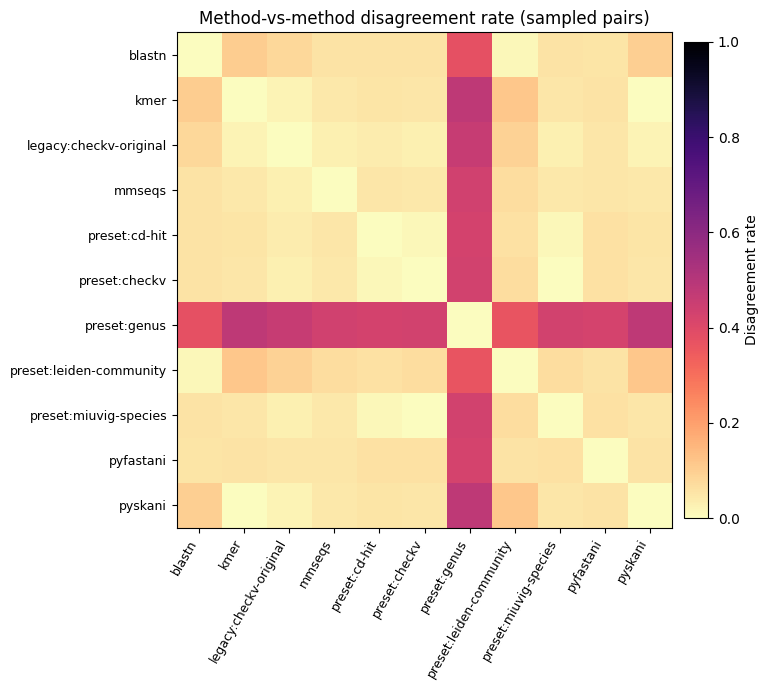

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [ ]:
from itertools import combinations

import matplotlib.pyplot as plt

# Build a unified map of method -> sequence cluster mapping
method_cluster_maps = {}
method_cluster_maps.update(cluster_map_by_backend)
for preset_name, preset_map in preset_cluster_maps.items():
    method_cluster_maps[f"preset:{preset_name}"] = preset_map

# Add legacy CheckV clustering if available
legacy_clusters_path = outdir / "legacy_checkv_clusters.tsv"
if legacy_clusters_path.exists():
    legacy_cluster_map: dict[str, str] = {}
    with open(legacy_clusters_path) as handle:
        for line in handle:
            row = line.rstrip("\n")
            if not row:
                continue
            centroid, members = row.split("\t", 1)
            for seq_id in members.split(","):
                legacy_cluster_map[seq_id] = centroid
    method_cluster_maps["legacy:checkv-original"] = legacy_cluster_map
else:
    print(f"Legacy CheckV clusters not found at {legacy_clusters_path}; skipping legacy in all-method heatmap")

method_names = sorted(method_cluster_maps.keys())
n_methods = len(method_names)

# Pairwise metrics on the same sampled pairs used above
pairwise_disagreement_matrix = [[0.0 for _ in range(n_methods)] for _ in range(n_methods)]
pairwise_jaccard_matrix = [[1.0 if i == j else 0.0 for j in range(n_methods)] for i in range(n_methods)]

for i, method_a in enumerate(method_names):
    map_a = method_cluster_maps[method_a]
    for j, method_b in enumerate(method_names):
        if j < i:
            pairwise_disagreement_matrix[i][j] = pairwise_disagreement_matrix[j][i]
            pairwise_jaccard_matrix[i][j] = pairwise_jaccard_matrix[j][i]
            continue

        map_b = method_cluster_maps[method_b]
        same_a = same_b = same_both = union = mismatch = 0
        valid_pairs = 0

        for idx_i, idx_j in pair_indices:
            seq_i = seq_ids[idx_i]
            seq_j = seq_ids[idx_j]

            a_i = map_a.get(seq_i)
            a_j = map_a.get(seq_j)
            b_i = map_b.get(seq_i)
            b_j = map_b.get(seq_j)

            in_a = (a_i is not None) and (a_j is not None)
            in_b = (b_i is not None) and (b_j is not None)
            if not (in_a and in_b):
                continue

            same_method_a = int(a_i == a_j)
            same_method_b = int(b_i == b_j)
            mismatch += int(same_method_a != same_method_b)

            same_a += same_method_a
            same_b += same_method_b
            same_both += int((same_method_a == 1) and (same_method_b == 1))
            union += int((same_method_a == 1) or (same_method_b == 1))
            valid_pairs += 1

        disagreement = mismatch / valid_pairs if valid_pairs else float("nan")
        jaccard = same_both / union if union else 1.0

        pairwise_disagreement_matrix[i][j] = disagreement
        pairwise_disagreement_matrix[j][i] = disagreement
        pairwise_jaccard_matrix[i][j] = jaccard
        pairwise_jaccard_matrix[j][i] = jaccard

# Plot disagreement heatmap (lower is more similar)
fig, ax = plt.subplots(figsize=(max(8, n_methods * 0.55), max(7, n_methods * 0.5)))
im = ax.imshow(pairwise_disagreement_matrix, cmap="magma_r", vmin=0.0, vmax=1.0)

ax.set_xticks(range(n_methods))
ax.set_xticklabels(method_names, rotation=60, ha="right", fontsize=9)
ax.set_yticks(range(n_methods))
ax.set_yticklabels(method_names, fontsize=9)
ax.set_title("Method-vs-method disagreement rate (sampled pairs)")

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Disagreement rate")

plt.tight_layout()
plt.show()

# Also emit as a sortable table for exact values
pairwise_rows = []
for i, j in combinations(range(n_methods), 2):
    pairwise_rows.append(
        {
            "method_a": method_names[i],
            "method_b": method_names[j],
            "disagreement_rate": pairwise_disagreement_matrix[i][j],
            "co_cluster_jaccard": pairwise_jaccard_matrix[i][j],
        }
    )

method_pairwise_comparison = (
    pl.DataFrame(pairwise_rows)
    .sort("disagreement_rate")
)

method_pairwise_comparison

## Legacy CheckV comparison (with timing)
Run original `anicalc.py` + `aniclust.py` on BLASTN input and compare presets against this legacy baseline.

In [ ]:
%%bash
set -euo pipefail
cd ../../../

OUTDIR="testing_folder/outputs/partiti_usecase"
TIMELOG="${OUTDIR}/cluster_timing.log"
INPUT_FASTA="${OUTDIR}/combined_rdrp_cp.fasta"
BLAST_RAW="${OUTDIR}/legacy_checkv_blastn_raw.tsv"
BLAST_SORTED="${OUTDIR}/legacy_checkv_blastn_sorted.tsv"
ANI_OUT="${OUTDIR}/legacy_checkv_ani.tsv"
ANI_NO_HEADER="${OUTDIR}/legacy_checkv_ani_no_header.tsv"
CLUSTERS_OUT="${OUTDIR}/legacy_checkv_clusters.tsv"

mkdir -p "${OUTDIR}"
echo "=== $(date -Is) legacy=checkv-original ===" >> "${TIMELOG}"

echo "Running legacy CheckV path on: ${INPUT_FASTA}"

/usr/bin/time -f "legacy_stage=blastn wall_s=%e user_cpu_s=%U sys_cpu_s=%S max_rss_kb=%M" \
  pixi run -e cluster blastn \
    -query "${INPUT_FASTA}" \
    -subject "${INPUT_FASTA}" \
    -dust no \
    -soft_masking false \
    -word_size 11 \
    -evalue 1e-5 \
    -outfmt '6 std qlen slen' \
    -num_threads 8 \
    -out "${BLAST_RAW}" 2> >(tee -a "${TIMELOG}" >&2)

sort -k1,1 -k2,2 "${BLAST_RAW}" > "${BLAST_SORTED}"

/usr/bin/time -f "legacy_stage=anicalc wall_s=%e user_cpu_s=%U sys_cpu_s=%S max_rss_kb=%M" \
  pixi run -e dev python notebooks/Exprimental/partiti_usecase/anicalc.py \
    -i "${BLAST_SORTED}" \
    -o "${ANI_OUT}" 2> >(tee -a "${TIMELOG}" >&2)

# aniclust.py expects no header in ANI input
awk 'NR>1' "${ANI_OUT}" > "${ANI_NO_HEADER}"

/usr/bin/time -f "legacy_stage=aniclust wall_s=%e user_cpu_s=%U sys_cpu_s=%S max_rss_kb=%M" \
  pixi run -e dev python notebooks/Exprimental/partiti_usecase/aniclust.py \
    --fna "${INPUT_FASTA}" \
    --ani "${ANI_NO_HEADER}" \
    --out "${CLUSTERS_OUT}" \
    --min_ani 95 \
    --min_qcov 0 \
    --min_tcov 85 2> >(tee -a "${TIMELOG}" >&2)

echo "Legacy outputs written to ${OUTDIR}"
wc -l "${BLAST_RAW}" "${ANI_OUT}" "${ANI_NO_HEADER}" "${CLUSTERS_OUT}"

Running legacy CheckV path on: testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta


blastn wall_s=330.59 user_cpu_s=325.61 sys_cpu_s=3.35 max_rss_kb=1695412
anicalc wall_s=32.36 user_cpu_s=25.87 sys_cpu_s=0.37 max_rss_kb=333536



reading sequences...
6054 sequences retained from fna
time: 0.03 seconds, peak RAM: 0.34 GB

storing edges...
306199 edges retained from blastani
306199 edges currently stored
time: 5.92 seconds, peak RAM: 0.34 GB

clustering...
451 total clusters
time: 5.92 seconds, peak RAM: 0.34 GB

writing clusters...
time: 5.94 seconds, peak RAM: 0.34 GB


aniclust wall_s=7.49 user_cpu_s=3.65 sys_cpu_s=0.21 max_rss_kb=342924


Legacy outputs written to testing_folder/outputs/partiti_usecase
  2693738 testing_folder/outputs/partiti_usecase/legacy_checkv_blastn_raw.tsv
  2638732 testing_folder/outputs/partiti_usecase/legacy_checkv_ani.tsv
  2638731 testing_folder/outputs/partiti_usecase/legacy_checkv_ani_no_header.tsv
      451 testing_folder/outputs/partiti_usecase/legacy_checkv_clusters.tsv
  7971652 total


Legacy cluster map loaded for 6054 sequences; missing from seq_ids: 0


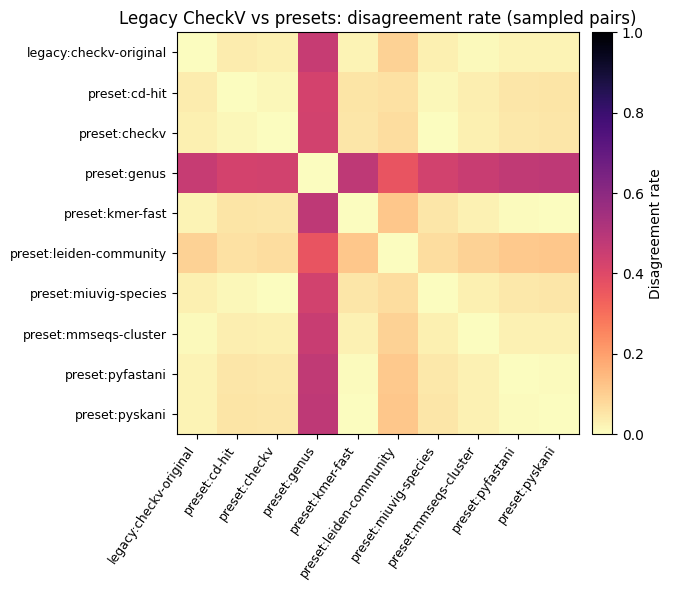

In [ ]:
from itertools import combinations

import matplotlib.pyplot as plt

legacy_clusters_path = outdir / "legacy_checkv_clusters.tsv"
if not legacy_clusters_path.exists():
    raise FileNotFoundError(
        f"Legacy CheckV cluster file not found: {legacy_clusters_path}. Run the timed shell cell first."
    )

legacy_cluster_map: dict[str, str] = {}
with open(legacy_clusters_path) as handle:
    for line in handle:
        row = line.rstrip("\n")
        if not row:
            continue
        centroid, members = row.split("\t", 1)
        for seq_id in members.split(","):
            legacy_cluster_map[seq_id] = centroid

legacy_missing = sum(1 for seq_id in seq_ids if seq_id not in legacy_cluster_map)
print(f"Legacy cluster map loaded for {len(legacy_cluster_map)} sequences; missing from seq_ids: {legacy_missing}")

# Compare presets against legacy CheckV clustering
legacy_rows = []
for preset_name, preset_map in preset_cluster_maps.items():
    same_legacy = 0
    same_preset = 0
    same_both = 0
    mismatch = 0
    valid_pairs = 0

    for i, j in pair_indices:
        seq_i = seq_ids[i]
        seq_j = seq_ids[j]

        legacy_i = legacy_cluster_map.get(seq_i)
        legacy_j = legacy_cluster_map.get(seq_j)
        preset_i = preset_map.get(seq_i)
        preset_j = preset_map.get(seq_j)

        if None in (legacy_i, legacy_j, preset_i, preset_j):
            continue

        in_legacy = legacy_i == legacy_j
        in_preset = preset_i == preset_j
        same_legacy += int(in_legacy)
        same_preset += int(in_preset)
        same_both += int(in_legacy and in_preset)
        mismatch += int(in_legacy != in_preset)
        valid_pairs += 1

    union = same_legacy + same_preset - same_both
    co_cluster_jaccard = (same_both / union) if union > 0 else 1.0
    disagreement = (mismatch / valid_pairs) if valid_pairs > 0 else float("nan")

    legacy_rows.append(
        {
            "preset": preset_name,
            "valid_pairs": valid_pairs,
            "co_cluster_jaccard_vs_legacy_checkv": round(co_cluster_jaccard, 4),
            "pairwise_disagreement_rate_vs_legacy_checkv": round(disagreement, 4),
            "n_clusters": len(set(preset_map.values())),
        }
    )

legacy_preset_comparison = pl.DataFrame(legacy_rows).sort("pairwise_disagreement_rate_vs_legacy_checkv")
legacy_preset_comparison

# Visualize pairwise disagreement for legacy + presets only
legacy_method_maps = {"legacy:checkv-original": legacy_cluster_map}
for preset_name, preset_map in preset_cluster_maps.items():
    legacy_method_maps[f"preset:{preset_name}"] = preset_map

legacy_methods = sorted(legacy_method_maps.keys())
n_legacy_methods = len(legacy_methods)
legacy_disagreement_matrix = [[0.0 for _ in range(n_legacy_methods)] for _ in range(n_legacy_methods)]

for i, method_a in enumerate(legacy_methods):
    map_a = legacy_method_maps[method_a]
    for j, method_b in enumerate(legacy_methods):
        if j < i:
            legacy_disagreement_matrix[i][j] = legacy_disagreement_matrix[j][i]
            continue

        map_b = legacy_method_maps[method_b]
        mismatch = 0
        valid_pairs = 0

        for idx_i, idx_j in pair_indices:
            seq_i = seq_ids[idx_i]
            seq_j = seq_ids[idx_j]

            a_i = map_a.get(seq_i)
            a_j = map_a.get(seq_j)
            b_i = map_b.get(seq_i)
            b_j = map_b.get(seq_j)
            if None in (a_i, a_j, b_i, b_j):
                continue

            mismatch += int((a_i == a_j) != (b_i == b_j))
            valid_pairs += 1

        disagreement = mismatch / valid_pairs if valid_pairs else float("nan")
        legacy_disagreement_matrix[i][j] = disagreement
        legacy_disagreement_matrix[j][i] = disagreement

fig, ax = plt.subplots(figsize=(max(8, n_legacy_methods * 0.7), max(6, n_legacy_methods * 0.6)))
im = ax.imshow(legacy_disagreement_matrix, cmap="magma_r", vmin=0.0, vmax=1.0)
ax.set_xticks(range(n_legacy_methods))
ax.set_xticklabels(legacy_methods, rotation=55, ha="right", fontsize=9)
ax.set_yticks(range(n_legacy_methods))
ax.set_yticklabels(legacy_methods, fontsize=9)
ax.set_title("Legacy CheckV vs presets: disagreement rate (sampled pairs)")
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Disagreement rate")
plt.tight_layout()
plt.show()

In [ ]:
legacy_preset_comparison

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [ ]:
for row in legacy_preset_comparison.iter_rows(named=True):
    print(row)

{'preset': 'mmseqs-cluster', 'valid_pairs': 200000, 'co_cluster_jaccard_vs_legacy_checkv': 0.6762, 'pairwise_disagreement_rate_vs_legacy_checkv': 0.0088, 'n_clusters': 466}
{'preset': 'pyskani', 'valid_pairs': 200000, 'co_cluster_jaccard_vs_legacy_checkv': 0.0083, 'pairwise_disagreement_rate_vs_legacy_checkv': 0.0215, 'n_clusters': 5673}
{'preset': 'kmer-fast', 'valid_pairs': 200000, 'co_cluster_jaccard_vs_legacy_checkv': 0.0214, 'pairwise_disagreement_rate_vs_legacy_checkv': 0.0215, 'n_clusters': 4339}
{'preset': 'pyfastani', 'valid_pairs': 200000, 'co_cluster_jaccard_vs_legacy_checkv': 0.0816, 'pairwise_disagreement_rate_vs_legacy_checkv': 0.022, 'n_clusters': 2430}
{'preset': 'miuvig-species', 'valid_pairs': 200000, 'co_cluster_jaccard_vs_legacy_checkv': 0.4338, 'pairwise_disagreement_rate_vs_legacy_checkv': 0.0274, 'n_clusters': 377}
{'preset': 'checkv', 'valid_pairs': 200000, 'co_cluster_jaccard_vs_legacy_checkv': 0.4338, 'pairwise_disagreement_rate_vs_legacy_checkv': 0.0274, 'n_c

### Timing summary
Parse and summarize timing lines collected in `testing_folder/outputs/partiti_usecase/cluster_timing.log`.

In [ ]:
import re


timing_log_path = outdir / "cluster_timing.log"

if not timing_log_path.exists():
    print(f"Timing log not found: {timing_log_path}")
    print("Run the timed backend/preset/legacy shell cells first.")
else:
    timing_rows = []
    pattern = re.compile(r"(?P<key>[A-Za-z_]+)=(?P<value>[^\s]+)")

    with open(timing_log_path) as handle:
        for line_number, raw_line in enumerate(handle, start=1):
            line = raw_line.strip()
            if (not line) or line.startswith("===") or ("wall_s=" not in line):
                continue

            parsed = {match.group("key"): match.group("value") for match in pattern.finditer(line)}
            row = {
                "line_number": line_number,
                "raw": line,
                "backend": parsed.get("backend"),
                "preset": parsed.get("preset"),
                "legacy_stage": parsed.get("legacy_stage"),
                "wall_s": float(parsed.get("wall_s", "nan")),
                "user_cpu_s": float(parsed.get("user_cpu_s", "nan")),
                "sys_cpu_s": float(parsed.get("sys_cpu_s", "nan")),
                "max_rss_kb": float(parsed.get("max_rss_kb", "nan")),
            }

            if row["backend"] is not None:
                row["method_group"] = "backend"
                row["method_name"] = row["backend"]
            elif row["preset"] is not None:
                row["method_group"] = "preset"
                row["method_name"] = row["preset"]
            elif row["legacy_stage"] is not None:
                row["method_group"] = "legacy"
                row["method_name"] = row["legacy_stage"]
            else:
                row["method_group"] = "other"
                row["method_name"] = "unknown"

            timing_rows.append(row)

    if not timing_rows:
        print(f"No timing lines parsed from {timing_log_path}")
    else:
        timing_df = pl.DataFrame(timing_rows).sort("line_number")

        timing_summary_latest = (
            timing_df
            .group_by(["method_group", "method_name"])
            .agg(
                pl.col("line_number").max().alias("last_seen_line"),
                pl.col("wall_s").last().alias("wall_s"),
                pl.col("user_cpu_s").last().alias("user_cpu_s"),
                pl.col("sys_cpu_s").last().alias("sys_cpu_s"),
                pl.col("max_rss_kb").last().alias("max_rss_kb"),
            )
            .with_columns(
                (pl.col("max_rss_kb") / 1024.0 / 1024.0).round(3).alias("max_rss_gb")
            )
            .sort(["method_group", "wall_s"], descending=[False, True])
        )

        print(f"Parsed {timing_df.height} timing lines from {timing_log_path}")
        timing_summary_latest

Timing log not found: /clusterfs/jgi/scratch/science/metagen/neri/code/rolypoly/testing_folder/outputs/partiti_usecase/cluster_timing.log
Run the timed backend/preset/legacy shell cells first.


### Preset comparison
Run preset configurations as-is, then compare their clustering behavior against the `blastn` baseline.

In [ ]:
asdasdasd

### Correlate
Prepare presence-absence matrix:
We consider a cluster is present in a sample if any cluster member is in that sample.

In [ ]:
# Build contig metadata: map each contig to its marker_type and sample_id
contig_meta = combined.select(
    pl.col("contig_id"),
    pl.col("marker_type"),
    pl.col("sample_id"),
    pl.col("sequence").str.len_bytes().alias("seq_length"),
)

# Join cluster assignments with contig metadata
cluster_with_meta = cluster_assignments.join(
    contig_meta, left_on="seq_id", right_on="contig_id", how="left"
)

# Build cluster summary: marker counts, sample presence, representative (longest seq)
cluster_summary = (
    cluster_with_meta
    .group_by("cluster_id")
    .agg(
        pl.len().alias("cluster_size"),
        (pl.col("marker_type") == "RdRp").sum().alias("n_rdrp_members"),
        (pl.col("marker_type") == "CP").sum().alias("n_cp_members"),
        pl.col("sample_id").n_unique().alias("n_samples"),
        pl.col("seq_id").sort_by("seq_length", descending=True).first().alias("representative_contig"),
        ((pl.col("marker_type") == "RdRp").sum() > 0).alias("has_rdrp"),
        ((pl.col("marker_type") == "CP").sum() > 0).alias("has_cp"),
    )
    .sort("cluster_size", descending=True)
)

# Build presence-absence matrix: cluster_id x sample_id (1/0)
cluster_sample_long = (
    cluster_with_meta
    .select("cluster_id", "sample_id")
    .unique()
    .with_columns(pl.lit(1).alias("present"))
)

all_samples = sorted(cluster_sample_long["sample_id"].unique().to_list())

presence_wide = (
    cluster_sample_long
    .pivot(on="sample_id", index="cluster_id", values="present")
    .fill_null(0)
    .select(["cluster_id"] + [s for s in all_samples if s in cluster_sample_long["sample_id"].unique().to_list()])
)

# Write presence-absence matrix for correlate
correlate_input = outdir / "cluster_presence_for_correlate.tsv"
presence_wide.write_csv(correlate_input, separator="\t")

print(f"Clusters: {cluster_summary.height}")
print(f"Samples:  {len(all_samples)}")
cluster_summary

run `rolypoly correlate`


In [ ]:
%%bash
cd ../../../
pixi run rolypoly correlate \
    -i testing_folder/outputs/partiti_usecase/cluster_presence_for_correlate.tsv \
    -o testing_folder/outputs/partiti_usecase/correlate/partiti \
    -m both \
    --method spearman \
    --min-prevalence 0.05 \
    --min-correlation 0.01 \
    --min-shared-samples 1 \
    -ll debug

### Add shared termini data
First run `extend` on the combined FASTA to build pileup-extended representatives per ANI cluster:

In [ ]:
%%bash
cd ../../../
pixi run rolypoly extend \
    -i testing_folder/outputs/partiti_usecase/combined_rdrp_cp.fasta \
    -o testing_folder/outputs/partiti_usecase/extend/partiti_extend.fasta \
    --clusters-output testing_folder/outputs/partiti_usecase/extend/partiti_extend.clusters.tsv \
    --ani-min-identity 0.9 \
    --ani-min-af 0.8 \
    --pileup-min-overlap 50 \
    --pileup-min-identity 0.98 \
    -t 8 \
    -ll debug

Read extend results, then run `termini` on the extended FASTA:

In [ ]:
%%bash
cd ../../../
pixi run rolypoly termini \
    -i testing_folder/outputs/partiti_usecase/extend/partiti_extend.fasta \
    -n 4-1145 \
    -d 0 \
    --max-clipped 4 \
    --strand both \
    --ani-prefilter \
    --ani-min-identity 0.95 \
    --ani-min-af 0.80 \
    -o testing_folder/outputs/partiti_usecase/termini/partiti_termini.tsv \
    --groups-output testing_folder/outputs/partiti_usecase/termini/partiti_termini.groups.tsv \
    --motifs-fasta testing_folder/outputs/partiti_usecase/termini/partiti_termini.motifs.fasta \
    -t 8 \
    -ll debug

### Aggregate results
combine the presence-absence/correlation results with the termini-group information.
Need to create a `putative_candidates` dataframe, with specs:
friendly_columns = {
    "cluster_a_id",
    "cluster_b_id",    
    "cluster_a_rdrp_count",
    "cluster_a_cp_count",
    "cluster_a_has_rdrp",
    "cluster_a_has_cp",
    "cluster_b_rdrp_count",
    "cluster_b_cp_count",
    "cluster_b_has_rdrp",
    "cluster_b_has_cp",
    "correlation": "presence_correlation",
    "co_present_sample_count",
    "is_both_rdrp_only",
    "is_both_cp_only",
    "passes_function_complementarity_check",
    "cluster_a_representative_contig",
    "cluster_b_representative_contig",
    "cluster_a_termini_group_1",
    "cluster_a_termini_group_2",
    "cluster_b_termini_group_1",
    "cluster_b_termini_group_2",
    "cluster_a_termini_seq_1",
    "cluster_a_termini_seq_2",
    "cluster_b_termini_seq_1",
    "cluster_b_termini_seq_2",
}

In [ ]:
# Read correlate outputs
correlation_pairs = pl.read_csv(outdir / "correlate/partiti.correlation_pairs.tsv", separator="\t")
cooccurrence_pairs = pl.read_csv(outdir / "correlate/partiti.cooccurrence_pairs.tsv", separator="\t")

# Read extend cluster membership
extend_clusters = pl.read_csv(outdir / "extend/partiti_extend.clusters.tsv", separator="\t")

# Read termini outputs
termini_assignments = pl.read_csv(outdir / "termini/partiti_termini.tsv", separator="\t")
termini_groups = pl.read_csv(outdir / "termini/partiti_termini.groups.tsv", separator="\t")

# Map cluster representatives from extend results (representative = longest/extended member)
cluster_reps = (
    extend_clusters
    .filter(pl.col("is_representative"))
    .select(
        pl.col("cluster_id"),
        pl.col("contig_id").alias("representative_contig"),
    )
)

# For each cluster, get the representative's termini assignments
rep_termini = cluster_reps.join(
    termini_assignments.select(
        "contig_id",
        "termini_group_1", "termini_group_1_motif",
        "termini_group_2", "termini_group_2_motif",
    ),
    left_on="representative_contig",
    right_on="contig_id",
    how="left",
)

# Start from cooccurrence pairs (cluster_id pairs that co-occur)
base_pairs = cooccurrence_pairs.rename({
    "contig_1": "cluster_a_id",
    "contig_2": "cluster_b_id",
    "shared_samples": "co_present_sample_count",
})

# Join with correlation values if not already present
if "correlation" not in base_pairs.columns:
    base_pairs = base_pairs.join(
        correlation_pairs.rename({
            "contig_1": "cluster_a_id",
            "contig_2": "cluster_b_id",
        }),
        on=["cluster_a_id", "cluster_b_id"],
        how="left",
    )

# Join cluster summary for marker counts (side a)
base_pairs = base_pairs.join(
    cluster_summary.select(
        pl.col("cluster_id").alias("cluster_a_id"),
        pl.col("n_rdrp_members").alias("cluster_a_rdrp_count"),
        pl.col("n_cp_members").alias("cluster_a_cp_count"),
        pl.col("has_rdrp").alias("cluster_a_has_rdrp"),
        pl.col("has_cp").alias("cluster_a_has_cp"),
    ),
    on="cluster_a_id",
    how="left",
)

# Join cluster summary for marker counts (side b)
base_pairs = base_pairs.join(
    cluster_summary.select(
        pl.col("cluster_id").alias("cluster_b_id"),
        pl.col("n_rdrp_members").alias("cluster_b_rdrp_count"),
        pl.col("n_cp_members").alias("cluster_b_cp_count"),
        pl.col("has_rdrp").alias("cluster_b_has_rdrp"),
        pl.col("has_cp").alias("cluster_b_has_cp"),
    ),
    on="cluster_b_id",
    how="left",
)

# Functional complementarity: one has RdRp-only, the other has CP-only
base_pairs = base_pairs.with_columns(
    (
        pl.col("cluster_a_has_rdrp") & ~pl.col("cluster_a_has_cp")
        & pl.col("cluster_b_has_rdrp") & ~pl.col("cluster_b_has_cp")
    ).alias("is_both_rdrp_only"),
    (
        pl.col("cluster_a_has_cp") & ~pl.col("cluster_a_has_rdrp")
        & pl.col("cluster_b_has_cp") & ~pl.col("cluster_b_has_rdrp")
    ).alias("is_both_cp_only"),
    (
        (pl.col("cluster_a_has_rdrp") & ~pl.col("cluster_a_has_cp")
         & pl.col("cluster_b_has_cp") & ~pl.col("cluster_b_has_rdrp"))
        | (pl.col("cluster_a_has_cp") & ~pl.col("cluster_a_has_rdrp")
           & pl.col("cluster_b_has_rdrp") & ~pl.col("cluster_b_has_cp"))
    ).alias("passes_function_complementarity_check"),
)

# Join representative contigs
base_pairs = (
    base_pairs
    .join(
        cluster_reps.rename({"cluster_id": "cluster_a_id", "representative_contig": "cluster_a_representative_contig"}),
        on="cluster_a_id", how="left",
    )
    .join(
        cluster_reps.rename({"cluster_id": "cluster_b_id", "representative_contig": "cluster_b_representative_contig"}),
        on="cluster_b_id", how="left",
    )
)

# Join termini group info for each cluster's representative
base_pairs = (
    base_pairs
    .join(
        rep_termini.select(
            pl.col("cluster_id").alias("cluster_a_id"),
            pl.col("termini_group_1").alias("cluster_a_termini_group_1"),
            pl.col("termini_group_2").alias("cluster_a_termini_group_2"),
            pl.col("termini_group_1_motif").alias("cluster_a_termini_seq_1"),
            pl.col("termini_group_2_motif").alias("cluster_a_termini_seq_2"),
        ),
        on="cluster_a_id", how="left",
    )
    .join(
        rep_termini.select(
            pl.col("cluster_id").alias("cluster_b_id"),
            pl.col("termini_group_1").alias("cluster_b_termini_group_1"),
            pl.col("termini_group_2").alias("cluster_b_termini_group_2"),
            pl.col("termini_group_1_motif").alias("cluster_b_termini_seq_1"),
            pl.col("termini_group_2_motif").alias("cluster_b_termini_seq_2"),
        ),
        on="cluster_b_id", how="left",
    )
)

# Select final columns matching the spec
putative_candidates = base_pairs.select(
    "cluster_a_id",
    "cluster_b_id",
    "cluster_a_rdrp_count",
    "cluster_a_cp_count",
    "cluster_a_has_rdrp",
    "cluster_a_has_cp",
    "cluster_b_rdrp_count",
    "cluster_b_cp_count",
    "cluster_b_has_rdrp",
    "cluster_b_has_cp",
    "correlation",
    "co_present_sample_count",
    "is_both_rdrp_only",
    "is_both_cp_only",
    "passes_function_complementarity_check",
    "cluster_a_representative_contig",
    "cluster_b_representative_contig",
    "cluster_a_termini_group_1",
    "cluster_a_termini_group_2",
    "cluster_b_termini_group_1",
    "cluster_b_termini_group_2",
    "cluster_a_termini_seq_1",
    "cluster_a_termini_seq_2",
    "cluster_b_termini_seq_1",
    "cluster_b_termini_seq_2",
)

# Write outputs
putative_candidates.write_csv(outdir / "candidate_pairs_rdrp_cp.tsv", separator="\t")

strict = putative_candidates.filter(pl.col("passes_function_complementarity_check"))
strict.write_csv(outdir / "candidate_pairs_rdrp_cp.strict.tsv", separator="\t")

print(f"Total candidate pairs: {putative_candidates.height}")
print(f"Strict (complementary) pairs: {strict.height}")
putative_candidates